# Objective: Perform GPU benchmarking

GPU benchmarking can mean many things:
1) Calculate peak flops at multiple precisions (Theoretical vs Practical)
2) Peak Memory bandwidth at multiple precisions
3) Ridge point

Below Ridge point:
1) You are memory bounded - Memory bandwidth is completly utilised with compute being idle
2) Fusing operations can be one of the way to utilise more compute per byte transferred.

Above Ridge point:
1) You are compute bounded - Compute is already at its peak flops and memory bus is underutilised.
2) When compute bounded, give more money to Nvidea and upgrade your GPU's compute.

# Calculating Peak Flops at multiple precisions

1) Precisions: FP16, FP32 (T4 is Turing, sm_75: no FP8 tensor cores, those need sm_89+)
2) Same dimension for all precisions: d = 8192
3) Elements per d x d tensor = 8192 * 8192 = 67,108,864
4) Flops per output element = 2 * d = 16,384 (one multiply + one add per term)
5) Total flops per matmul = 2 * d^3 ~ 1.1 TFLOP

Memory per tensor = d * d * bytes per element:
- FP16 (2 bytes): 128 MiB per tensor, 384 MiB for A, B, result
- FP32 (4 bytes): 256 MiB per tensor, 768 MiB for A, B, result

T4 spec-sheet peaks: FP16 tensor cores 65 TFLOP/s, FP32 8.1 TFLOP/s

In [86]:
import torch, subprocess, pandas as pd, io

TERA = 1e12
GIGA = 1e9  # decimal, matches the spec sheet's GB/s
PEAK_FP16_FLOPS_PER_SECOND = 65 * TERA
PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND = 320 * GIGA  # same for every precision
TENSOR_DIMENSION = 8192
FLOPS_PER_MATMUL = 2*TENSOR_DIMENSION**3
MILLISECONDS_PER_SECOND = 1e3
DEVICE = torch.device("cuda")
REPEATS = 100
SAMPLING_INTERVAL_MILLISECONDS = 100

GPU_STATS_QUERY = "clocks.sm,clocks.max.sm,power.draw,power.limit,temperature.gpu,utilization.gpu,clocks_throttle_reasons.sw_power_cap,clocks_throttle_reasons.sw_thermal_slowdown,clocks_throttle_reasons.hw_slowdown"
BUSY_UTILIZATION_PERCENT = 90  # keep only samples taken while the matmul was running

In [74]:
#FP16
fp16_dtype= torch.float16
tensor_a = torch.randn(TENSOR_DIMENSION, TENSOR_DIMENSION, device=DEVICE, dtype=fp16_dtype)
tensor_b = torch.randn(TENSOR_DIMENSION, TENSOR_DIMENSION, device=DEVICE, dtype=fp16_dtype)

#warm up
tensor_a @ tensor_b
start_event = torch.cuda.Event(enable_timing=True)
end_event = torch.cuda.Event(enable_timing=True)
torch.cuda.synchronize()

sampler = subprocess.Popen(
    ["nvidia-smi", f"--query-gpu={GPU_STATS_QUERY}", "--format=csv,noheader,nounits", "-lms", str(SAMPLING_INTERVAL_MILLISECONDS)],
    stdout=subprocess.PIPE, text=True,
)

start_event.record()
for _ in range(REPEATS):
    result = tensor_a @ tensor_b

end_event.record()
torch.cuda.synchronize()

sampler.terminate()
gpu_stats = pd.read_csv(io.StringIO(sampler.communicate()[0]), names=GPU_STATS_QUERY.split(","), skipinitialspace=True)
busy_stats = gpu_stats[gpu_stats["utilization.gpu"] >= BUSY_UTILIZATION_PERCENT]
mean_clock_mhz = busy_stats["clocks.sm"].mean()
max_clock_mhz = busy_stats["clocks.max.sm"].max()
clock_adjusted_peak = PEAK_FP16_FLOPS_PER_SECOND * mean_clock_mhz / max_clock_mhz

seconds_per_matmul = start_event.elapsed_time(end_event) / REPEATS / MILLISECONDS_PER_SECOND
achieved_flops_per_second = FLOPS_PER_MATMUL/seconds_per_matmul

print(f"Time per matmul:     {seconds_per_matmul * MILLISECONDS_PER_SECOND:.1f} ms")
print(f"Achieved:            {achieved_flops_per_second/TERA:.1f} TFLOP/s ({achieved_flops_per_second/PEAK_FP16_FLOPS_PER_SECOND:.0%} of spec peak)")
print(f"SM clock:            {mean_clock_mhz:.0f} MHz mean vs {max_clock_mhz:.0f} MHz boost")
print(f"Clock-adjusted peak: {clock_adjusted_peak/TERA:.1f} TFLOP/s -> achieved is {achieved_flops_per_second/clock_adjusted_peak:.0%} of it")
print(f"Power:               {busy_stats['power.draw'].mean():.1f} W mean / {busy_stats['power.limit'].max():.0f} W limit")
print(f"Temperature:         {busy_stats['temperature.gpu'].max()} C max")
for reason in ["clocks_throttle_reasons.sw_power_cap", "clocks_throttle_reasons.sw_thermal_slowdown", "clocks_throttle_reasons.hw_slowdown"]:
    print(f"{reason.split('.')[-1]:<20} active in {(busy_stats[reason] == 'Active').mean():.0%} of samples")


Time per matmul:     63.8 ms
Achieved:            17.2 TFLOP/s (27% of spec peak)
SM clock:            479 MHz mean vs 1590 MHz boost
Clock-adjusted peak: 19.6 TFLOP/s -> achieved is 88% of it
Power:               65.5 W mean / 70 W limit
Temperature:         82 C max
sw_power_cap         active in 100% of samples
sw_thermal_slowdown  active in 0% of samples
hw_slowdown          active in 0% of samples


### Why only 28% of peak?

1. Achieved: 18.4 TFLOP/s vs 65 TFLOP/s on the spec sheet (28%).
2. Peak FLOP/s scales linearly with SM clock. The 65 TFLOP/s assumes the 1590 MHz boost clock, but the mean clock during the matmul was only 506 MHz.
3. Clock-adjusted peak = 65 × 506 / 1590 = 20.7 TFLOP/s. Achieved is 89% of that, so the clock explains almost the entire gap.
4. Why the clock dropped: `sw_power_cap` was active in 100% of samples, with power at 66 W against the T4's 70 W limit. Thermal and hardware slowdown were 0%, so heat was not the cause.
5. A dense FP16 matmul keeps every tensor core switching every cycle, which is the most power-hungry thing the GPU does. The driver lowers the clock until power fits in 70 W; at this activity that is about 500 MHz.
6. The remaining ~11% is the cuBLAS kernel's own overhead (tile loads, synchronisation, writing results).

**Takeaway:** on a power-limited card like the T4, the spec-sheet peak is only reachable for short bursts or light loads. Under sustained dense matmuls, the practical ceiling is about 20 TFLOP/s, and that measured value (not 65) is the one to use for the ridge point.

In [87]:
# Memory bandwidth and arithmetic intensity of the previous matmul
bytes_per_tensor = TENSOR_DIMENSION**2 * tensor_a.element_size()
bytes_per_matmul = 2 * bytes_per_tensor + 1 * bytes_per_tensor  # read A, B + write result (lower bound)

achieved_bytes_per_second = bytes_per_matmul / seconds_per_matmul
print(f"Bytes per matmul:    {bytes_per_matmul/GIGA:.2f} GB")
print(f"Achieved bandwidth:  {achieved_bytes_per_second/GIGA:.2f} GB/s ({achieved_bytes_per_second/PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND:.1%} of spec)")

arithmetic_intensity = FLOPS_PER_MATMUL / bytes_per_matmul  # = d/3 FLOP/byte for FP16
spec_ridge_point = PEAK_FP16_FLOPS_PER_SECOND / PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND
clock_adjusted_ridge_point = clock_adjusted_peak / PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND
print(f"Arithmetic intensity: {arithmetic_intensity:.0f} FLOP/byte")
print(f"Ridge point:          {spec_ridge_point:.0f} FLOP/byte (spec), {clock_adjusted_ridge_point:.0f} FLOP/byte (clock-adjusted)")
print(f"-> {arithmetic_intensity/clock_adjusted_ridge_point:.0f}x past the ridge: compute-bound")

Bytes per matmul:    0.40 GB
Achieved bandwidth:  6.31 GB/s (2.0% of spec)
Arithmetic intensity: 2731 FLOP/byte
Ridge point:          203 FLOP/byte (spec), 61 FLOP/byte (clock-adjusted)
-> 45x past the ridge: compute-bound


# Roofline sweep: matmul size vs FLOP/s and bandwidth

For a d x d FP16 matmul, arithmetic intensity = 2d³ / (3 · 2d²) = d/3 FLOP/byte.
Sweeping d moves the matmul along the roofline:
- Large d: right of the ridge, compute-bound. FLOP/s should stay flat at the ceiling, bandwidth used is low.
- Small d: left of the ridge, memory-bound. FLOP/s falls with intensity, bandwidth used should approach the bus limit.
- The clock-adjusted ridge (~65 FLOP/byte) sits at d ≈ 195.

In [88]:
DIMENSION_SWEEP = [2**exponent for exponent in range(6, 14)]  # 64 .. 8192
SWEEP_WARMUP_ITERATIONS = 5
SWEEP_TIMING_ITERATIONS = 50

sweep_rows = []
for dimension in DIMENSION_SWEEP:
    sweep_a = torch.randn(dimension, dimension, device=DEVICE, dtype=fp16_dtype)
    sweep_b = torch.randn(dimension, dimension, device=DEVICE, dtype=fp16_dtype)
    for _ in range(SWEEP_WARMUP_ITERATIONS):
        sweep_a @ sweep_b
    torch.cuda.synchronize()

    start_event.record()
    for _ in range(SWEEP_TIMING_ITERATIONS):
        sweep_a @ sweep_b
    end_event.record()
    torch.cuda.synchronize()

    seconds = start_event.elapsed_time(end_event) / SWEEP_TIMING_ITERATIONS / MILLISECONDS_PER_SECOND
    flops = 2 * dimension**3
    bytes_moved = 3 * dimension**2 * sweep_a.element_size()
    sweep_rows.append({
        "d": dimension,
        "intensity (FLOP/byte)": flops / bytes_moved,
        "time (us)": seconds * 1e6,
        "TFLOP/s": flops / seconds / TERA,
        "GB/s": bytes_moved / seconds / GIGA,
    })

sweep_results = pd.DataFrame(sweep_rows)
print(sweep_results.round(2).to_string(index=False))

   d  intensity (FLOP/byte)  time (us)  TFLOP/s  GB/s
  64                  21.33      26.74     0.02  0.92
 128                  42.67      27.95     0.15  3.52
 256                  85.33      27.24     1.23 14.44
 512                 170.67      38.43     6.98 40.92
1024                 341.33     144.84    14.83 43.44
2048                 682.67     965.92    17.79 26.05
4096                1365.33    8229.55    16.70 12.23
8192                2730.67   61716.41    17.82  6.52


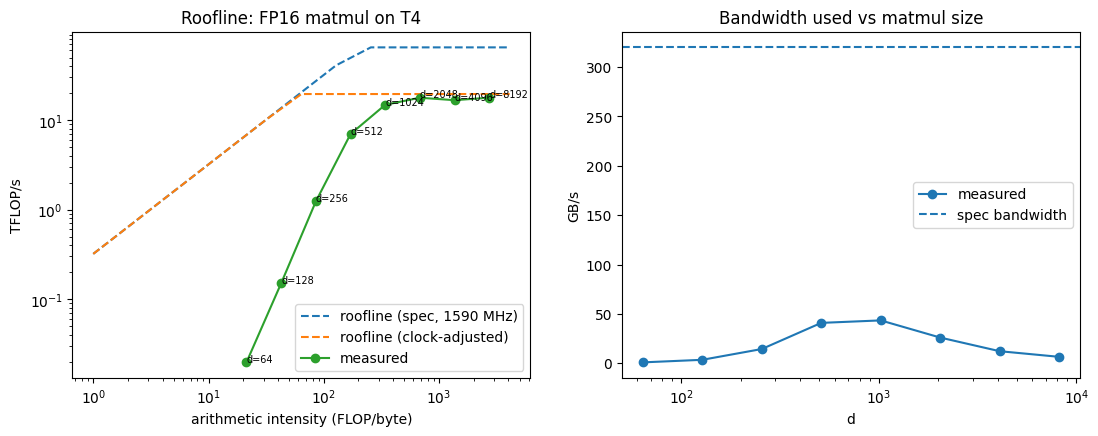

In [89]:
import matplotlib.pyplot as plt

intensity_axis_values = [2**exponent for exponent in range(0, 13)]
roofline_spec = [min(PEAK_FP16_FLOPS_PER_SECOND, intensity * PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND) / TERA for intensity in intensity_axis_values]
roofline_clock_adjusted = [min(clock_adjusted_peak, intensity * PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND) / TERA for intensity in intensity_axis_values]

figure, (roofline_axis, bandwidth_axis) = plt.subplots(1, 2, figsize=(13, 4.5))
roofline_axis.plot(intensity_axis_values, roofline_spec, "--", label="roofline (spec, 1590 MHz)")
roofline_axis.plot(intensity_axis_values, roofline_clock_adjusted, "--", label="roofline (clock-adjusted)")
roofline_axis.plot(sweep_results["intensity (FLOP/byte)"], sweep_results["TFLOP/s"], "o-", label="measured")
for _, row in sweep_results.iterrows():
    roofline_axis.annotate(f"d={row['d']:.0f}", (row["intensity (FLOP/byte)"], row["TFLOP/s"]), fontsize=7)
roofline_axis.set(xscale="log", yscale="log", xlabel="arithmetic intensity (FLOP/byte)", ylabel="TFLOP/s", title="Roofline: FP16 matmul on T4")
roofline_axis.legend()

bandwidth_axis.plot(sweep_results["d"], sweep_results["GB/s"], "o-", label="measured")
bandwidth_axis.axhline(PEAK_MEMORY_BANDWIDTH_BYTES_PER_SECOND / GIGA, linestyle="--", label="spec bandwidth")
bandwidth_axis.set(xscale="log", xlabel="d", ylabel="GB/s", title="Bandwidth used vs matmul size")
bandwidth_axis.legend()
plt.show()

### What to look for

1. Large d (2048-8192): TFLOP/s near the clock-adjusted ceiling and flat, bandwidth used far below the bus limit. Compute-bound.
2. As d shrinks, bandwidth used rises but TFLOP/s does not rise. At best it stays flat, then it drops.
3. FLOP/s drops before the ridge (d ≈ 195), not exactly at it: small matmuls have too few tiles to fill 40 SMs, and per-kernel launch overhead (a few µs) dominates.
4. Small d: A, B and result fit in the 4 MB L2 (d=512 FP16 is 1.5 MB), so bytes never reach DRAM and GB/s can be misleading.
5. Smaller matmuls draw less power, so the clock may rise and large-d points can even beat the earlier 8192 run. Compare with the clock printout if numbers look off.